# 🏋️ Calories Burned 예측 — 완전 파이프라인
> XGBoost · LightGBM · CatBoost + Optuna 튜닝 + 앙상블

| 항목 | 내용 |
|---|---|
| 목표 | Calories_Burned 예측 (RMSE 최소화) |
| 모델 | XGBoost, LightGBM, CatBoost |
| 튜닝 | Optuna TPESampler |
| 검증 | 5-Fold OOF |
| 앙상블 | 최적 가중평균 |

In [1]:
# ─────────────────────────────────────────────
# 0. 라이브러리
# ─────────────────────────────────────────────

!pip install optuna lightgbm xgboost catboost koreanize-matplotlib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, random, os, time, json

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')

# 한글 폰트
try:
    import koreanize_matplotlib
except ImportError:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print('✅ 라이브러리 로드 완료')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 51.1 MB/s eta 0:00:00
✅ 라이브러리 로드 완료


In [2]:
# ─────────────────────────────────────────────
# 1. 시드 고정
# ─────────────────────────────────────────────
SEED = 42

def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(SEED)
print(f'✅ SEED = {SEED}')


✅ SEED = 42


## 📥 학습/테스트 데이터 분리 로드
> **핵심 원칙**: train과 test는 절대 합치지 않는다.  
> 전처리 함수를 공통으로 만들고, **fit은 train 기준 → test에는 transform만** 적용한다.

In [3]:
# ─────────────────────────────────────────────
# 2. 데이터 로드
# ─────────────────────────────────────────────
# ❗ train / test 는 따로 로드 — 절대 합치지 않는다
#    전처리 함수를 공통으로 만들고 각각에 적용 (fit은 train 기준)

train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train : {train.shape}  |  Test : {test.shape}')
print()
print('Train columns:', train.columns.tolist())
print('Test  columns:', test.columns.tolist())
print()
print('Train dtypes:')
print(train.dtypes)
print()
print('결측치 (Train):', train.isnull().sum().sum())
print('결측치 (Test) :', test.isnull().sum().sum())


Train : (7500, 11)  |  Test : (7500, 10)

Train columns: ['ID', 'Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)', 'Height(Remainder_Inches)', 'Weight(lb)', 'Weight_Status', 'Gender', 'Age', 'Calories_Burned']
Test  columns: ['ID', 'Exercise_Duration', 'Body_Temperature(F)', 'BPM', 'Height(Feet)', 'Height(Remainder_Inches)', 'Weight(lb)', 'Weight_Status', 'Gender', 'Age']

Train dtypes:
ID                           object
Exercise_Duration           float64
Body_Temperature(F)         float64
BPM                         float64
Height(Feet)                float64
Height(Remainder_Inches)    float64
Weight(lb)                  float64
Weight_Status                object
Gender                       object
Age                           int64
Calories_Burned             float64
dtype: object

결측치 (Train): 0
결측치 (Test) : 0


## 🔍EDA & 시각화
> - 수치형 분포, 범주형 비율, 타겟 분포, 상관관계, 산점도, 박스플롯을 한눈에 확인  
> - **시각화는 train 데이터만** 사용 (test 참조 → 데이터 누수)


  Train EDA
                           count        mean        std   min    25%    50%    75%    max
Exercise_Duration         7500.0   15.501200   8.355300   1.0    8.0   15.0   23.0   30.0
Body_Temperature(F)       7500.0  104.033573   1.412845  98.8  103.3  104.4  105.1  106.7
BPM                       7500.0   95.498133   9.587331  69.0   88.0   95.0  103.0  128.0
Height(Feet)              7500.0    5.248800   0.556663   4.0    5.0    5.0    6.0    7.0
Height(Remainder_Inches)  7500.0    5.717600   3.497315   0.0    3.0    6.0    9.0   12.0
Weight(lb)                7500.0  165.361187  33.308136  79.4  138.9  163.1  191.8  291.0
Age                       7500.0   42.636000  16.883188  20.0   28.0   39.0   56.0   79.0
Calories_Burned           7500.0   89.373467  62.817086   1.0   35.0   77.0  138.0  300.0

결측치:
ID                          0
Exercise_Duration           0
Body_Temperature(F)         0
BPM                         0
Height(Feet)                0
Height(Remainder_Inch

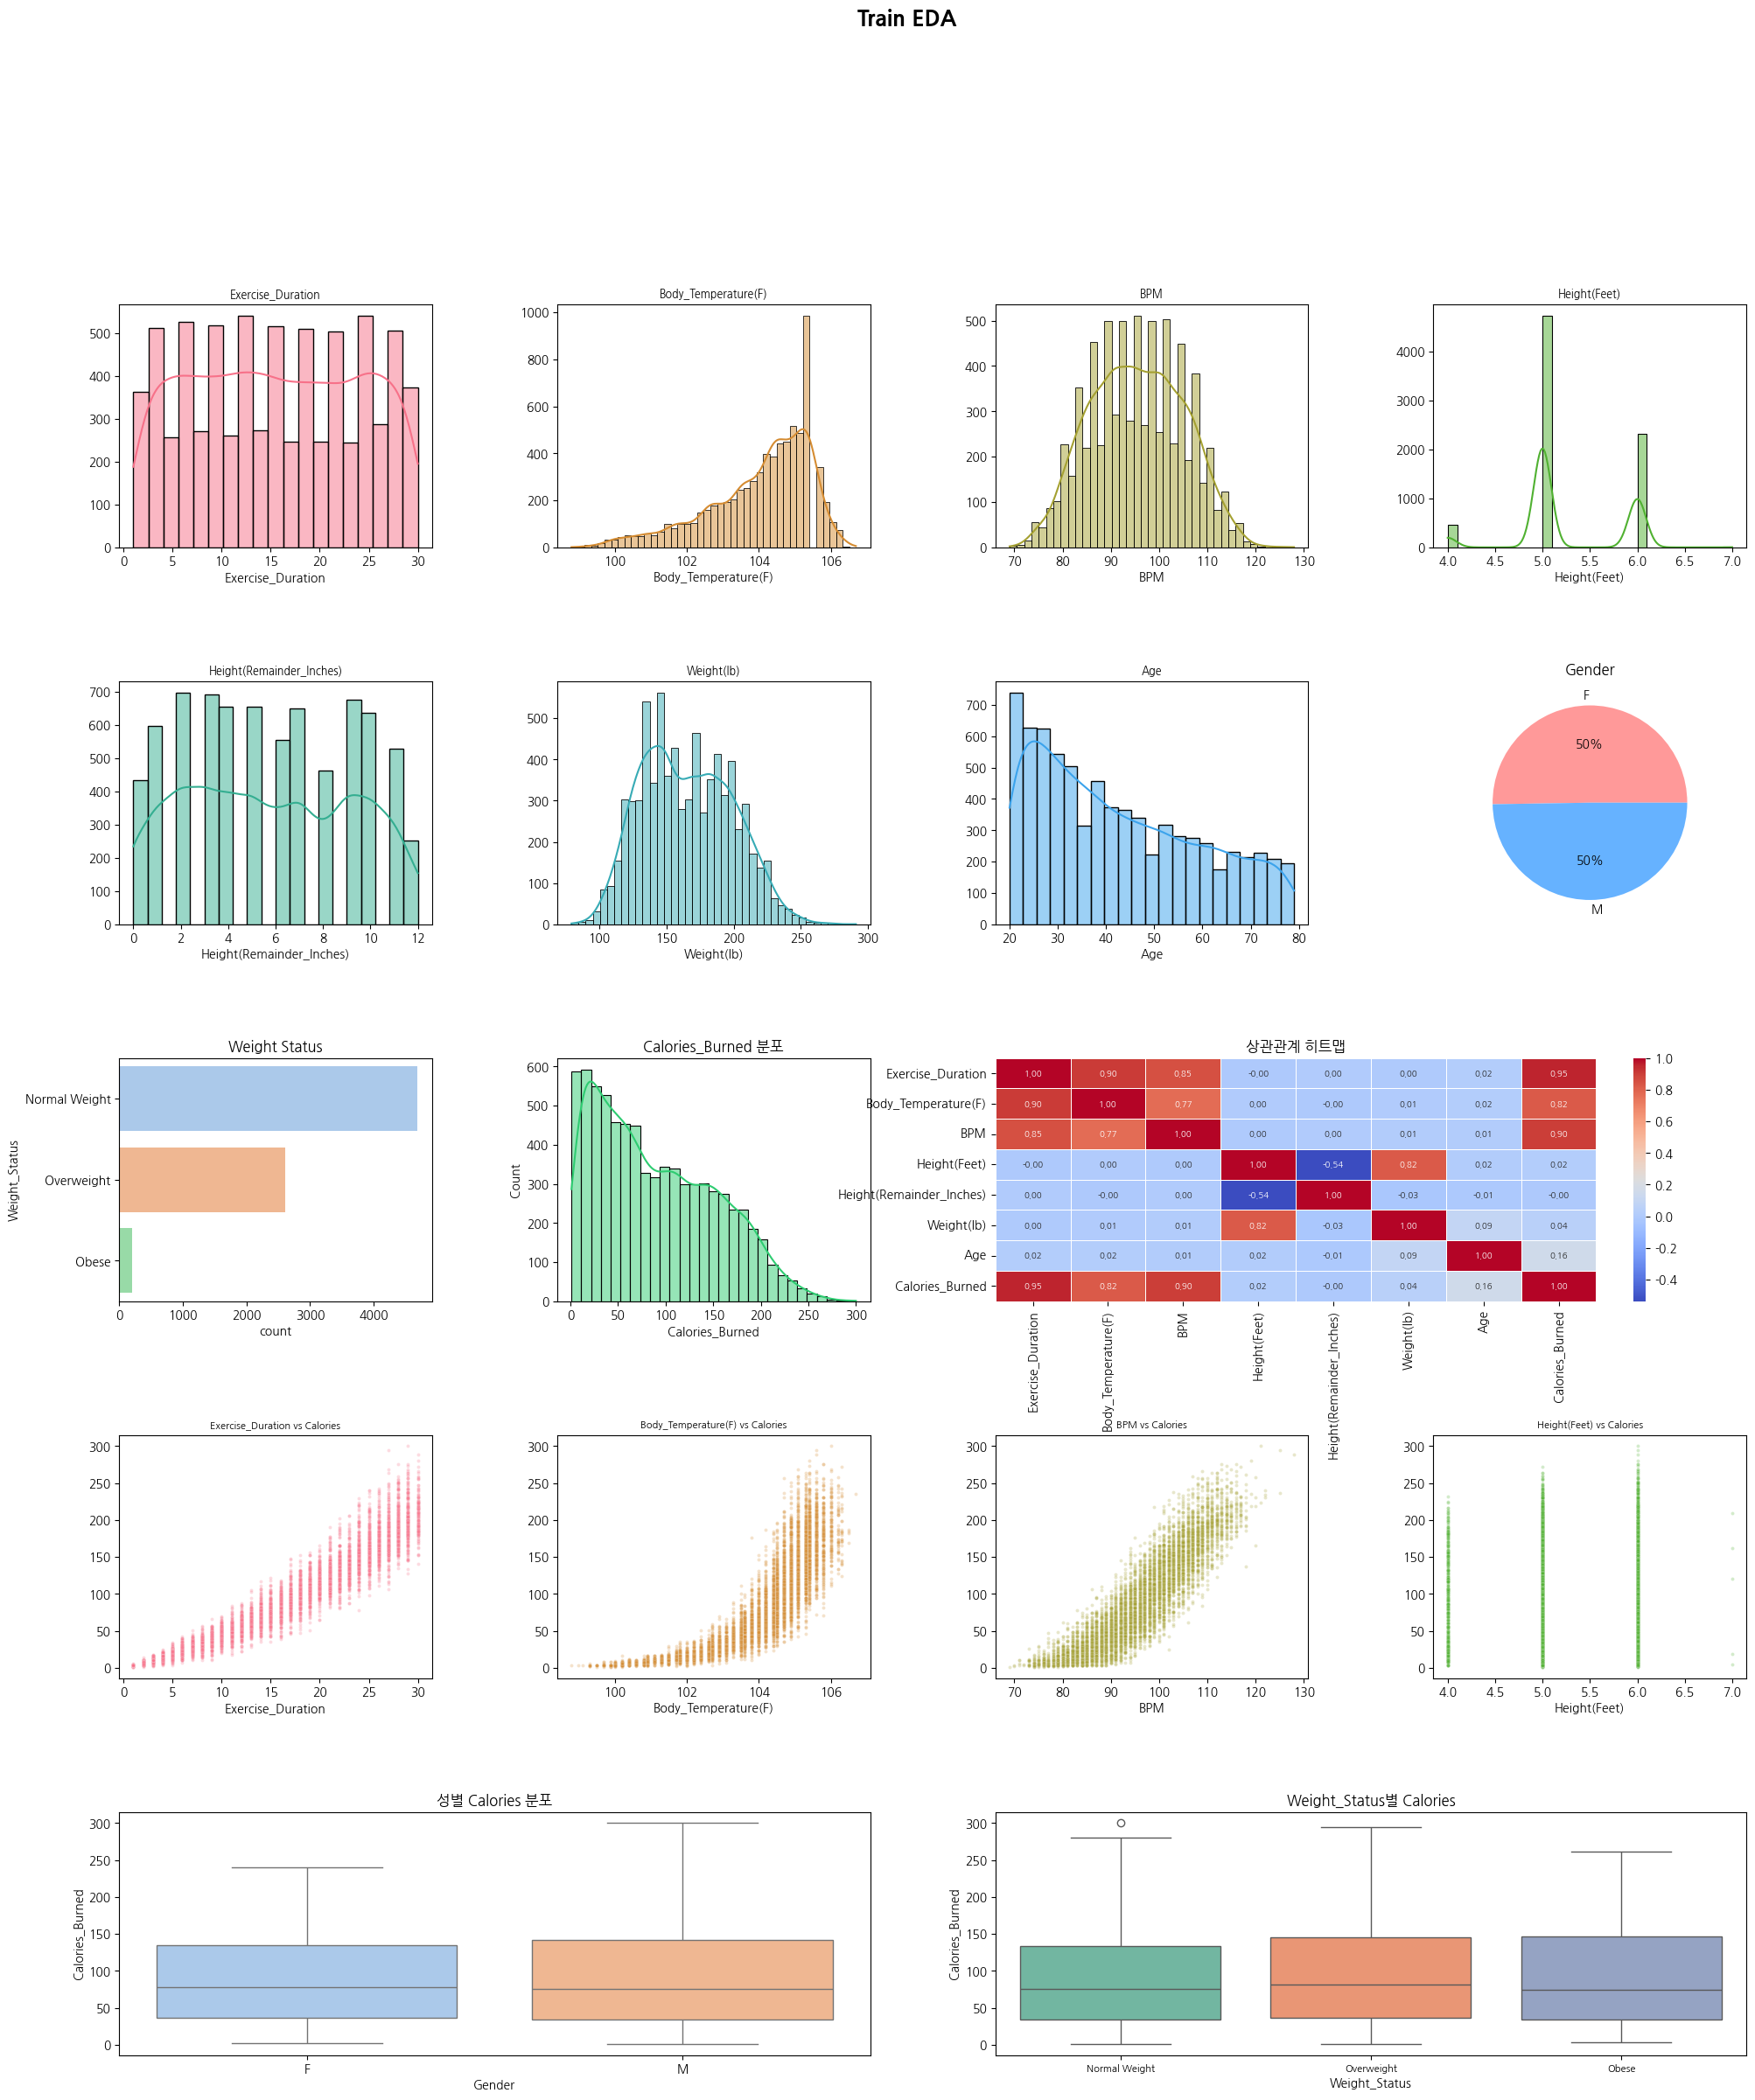

✅ EDA 저장 → eda_plot.png


In [4]:
# ─────────────────────────────────────────────
# 3. EDA
# ─────────────────────────────────────────────
def run_eda(df: pd.DataFrame, title: str = 'Train EDA'):
    print(f'\n{"="*60}')
    print(f'  {title}')
    print(f'{"="*60}')
    print(df.describe().T.to_string())
    print('\n결측치:')
    print(df.isnull().sum())

    num_cols = ['Exercise_Duration', 'Body_Temperature(F)', 'BPM',
                'Height(Feet)', 'Height(Remainder_Inches)', 'Weight(lb)', 'Age']

    fig = plt.figure(figsize=(24, 26))
    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.01)
    gs  = gridspec.GridSpec(5, 4, figure=fig, hspace=0.55, wspace=0.4)
    pal = sns.color_palette('husl', 9)

    # ── 수치형 KDE 분포
    for i, col in enumerate(num_cols):
        ax = fig.add_subplot(gs[i // 4, i % 4])
        sns.histplot(df[col], kde=True, ax=ax, color=pal[i])
        ax.set_title(col, fontsize=9)
        ax.set_ylabel('')

    # ── 성별 파이
    ax_g = fig.add_subplot(gs[1, 3])
    df['Gender'].value_counts().plot.pie(autopct='%1.0f%%', ax=ax_g,
                                          colors=['#FF9999','#66B2FF'])
    ax_g.set_title('Gender')
    ax_g.set_ylabel('')

    # ── Weight_Status 카운트
    ax_w = fig.add_subplot(gs[2, 0])
    order = ['Normal Weight','Overweight','Obese']
    sns.countplot(y='Weight_Status', data=df, order=order, ax=ax_w, palette='pastel')
    ax_w.set_title('Weight Status')

    if 'Calories_Burned' in df.columns:
        # ── 타겟 분포
        ax_t = fig.add_subplot(gs[2, 1])
        sns.histplot(df['Calories_Burned'], kde=True, ax=ax_t, color='#2ECC71')
        ax_t.set_title('Calories_Burned 분포')

        # ── 상관관계 히트맵
        ax_c = fig.add_subplot(gs[2, 2:4])
        corr = df[num_cols + ['Calories_Burned']].corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                    ax=ax_c, linewidths=0.5, annot_kws={'size':7})
        ax_c.set_title('상관관계 히트맵')

        # ── 수치형 vs 타겟 산점도
        for i, col in enumerate(num_cols[:4]):
            ax = fig.add_subplot(gs[3, i])
            sns.scatterplot(x=col, y='Calories_Burned', data=df,
                            ax=ax, alpha=0.25, s=8, color=pal[i])
            ax.set_title(f'{col} vs Calories', fontsize=8)
            ax.set_ylabel('')

        # ── 성별 박스플롯
        ax_gb = fig.add_subplot(gs[4, 0:2])
        sns.boxplot(x='Gender', y='Calories_Burned', data=df,
                    ax=ax_gb, palette='pastel')
        ax_gb.set_title('성별 Calories 분포')

        # ── Weight_Status 박스플롯
        ax_wb = fig.add_subplot(gs[4, 2:4])
        sns.boxplot(x='Weight_Status', y='Calories_Burned', data=df,
                    order=order, ax=ax_wb, palette='Set2')
        ax_wb.set_title('Weight_Status별 Calories')
        ax_wb.tick_params(axis='x', labelsize=8)

    plt.savefig('eda_plot.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('✅ EDA 저장 → eda_plot.png')

run_eda(train, 'Train EDA')


## ⚙️전처리 & 피처 엔지니어링
> **누수 방지 원칙** — `add_features()`는 순수 수식 변환만 수행 (train/test 통계 참조 없음)

In [5]:
# ─────────────────────────────────────────────
# 4. 피처 엔지니어링
# ─────────────────────────────────────────────
# ❗ 누수 방지:
#   · add_features() 내부에서 train 통계(mean, std 등) 절대 사용 금지
#   · 오직 수식 변환(단위 변환, 비율, 곱 등)만 허용

def get_activity_intensity(bpm_series, age_series):
    ages      = np.array([15,20,25,30,35,40,45,50,55,60,65,70,75,80,85,95], dtype=float)
    low_cuts  = np.array([126,124,122,120,117,115,113,111,109,107,105,102,100,98,96,92], dtype=float)
    high_cuts = np.array([150,147,145,142,139,137,134,132,129,127,124,122,119,117,114,109], dtype=float)

    age = pd.to_numeric(age_series, errors='coerce').astype(float).to_numpy()
    bpm = pd.to_numeric(bpm_series, errors='coerce').astype(float).to_numpy()
    low  = np.interp(age, ages, low_cuts)
    high = np.interp(age, ages, high_cuts)
    return pd.Series(
        np.where(bpm < low, 0, np.where(bpm < high, 1, 2)),
        index=bpm_series.index
    )


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # 단위 변환
    d['height_in'] = d['Height(Feet)'] * 12 + d['Height(Remainder_Inches)']
    d['height_cm'] = d['height_in'] * 2.54
    d['height_m']  = d['height_cm'] / 100.0
    d['weight_kg'] = d['Weight(lb)'] * 0.45359237
    d['temp_c']    = (d['Body_Temperature(F)'] - 32) * (5/9)

    # 신체 지수
    d['bmi'] = d['weight_kg'] / d['height_m'] ** 2

    # Harris-Benedict BMR
    is_male = d['Gender'].astype(str).str.upper().isin(['M','MALE'])
    d['bmr'] = np.where(
        is_male,
        66.47  + 13.75 * d['weight_kg'] + 5.0  * d['height_cm'] - 6.76 * d['Age'],
        655.1  + 9.56  * d['weight_kg'] + 1.85 * d['height_cm'] - 4.68 * d['Age']
    )

    # 심박 지표
    d['mhr']       = 220 - d['Age']
    d['hrr']       = d['mhr'] - 60
    d['hrr_ratio'] = (d['BPM'] - 60) / d['hrr'].clip(lower=1)
    d['hb_stress'] = d['BPM'] / d['mhr']

    # 운동 부하 지표
    d['metabolic_stress']  = d['BPM'] * d['Exercise_Duration']
    d['relative_workload'] = (d['BPM'] * d['weight_kg'] * d['Exercise_Duration']) / d['Age'].clip(lower=1)
    d['thermal_load']      = (d['temp_c'] - 37) * d['Exercise_Duration']
    d['intensity_index']   = d['BPM'] / d['Exercise_Duration'].clip(lower=1)

    # 핵심 교호작용
    d['HR_Temp_Interaction']     = d['BPM'] * d['temp_c']
    d['HR_Duration_Interaction'] = d['BPM'] * d['Exercise_Duration']
    d['Metabolic_Load']          = d['BPM'] * d['temp_c'] * d['Exercise_Duration']
    d['Age_Duration']            = d['Age'] * d['Exercise_Duration']
    d['Age_Body_Temp']           = d['Age'] * d['temp_c']
    d['Duration_Body_Temp']      = d['Exercise_Duration'] * d['temp_c']

    # 체중·신장 교호작용
    d['Weight_Duration']  = d['weight_kg'] * d['Exercise_Duration']
    d['Weight_HeartRate'] = d['weight_kg'] * d['BPM']
    d['Weight_HR_Duration'] = d['weight_kg'] * d['BPM'] * d['Exercise_Duration']
    d['Energy_Exerted']   = d['weight_kg'] * d['BPM'] * d['Exercise_Duration'] / 10000

    # BMR 교호작용
    d['BMR_HR']       = d['bmr'] * d['BPM']
    d['BMR_Duration'] = d['bmr'] * d['Exercise_Duration']
    d['BMR_Temp']     = d['bmr'] * d['temp_c']
    d['BMR_Intensity']= d['bmr'] * d['intensity_index']

    # 다항·로그 특성
    d['HR_Squared']       = d['BPM'] ** 2
    d['Duration_Squared'] = d['Exercise_Duration'] ** 2
    d['Log_HR']           = np.log1p(d['BPM'])
    d['Log_Duration']     = np.log1p(d['Exercise_Duration'])
    d['Log_Weight']       = np.log1p(d['weight_kg'])
    d['Log_BMR']          = np.log1p(d['bmr'])

    # 성별 교호작용 (Gender 인코딩 전에 수행)
    is_m = d['Gender'].astype(str).str.upper().isin(['M','MALE']).astype(int)
    d['Sex_male_HR']       = d['BPM']       * is_m
    d['Sex_female_HR']     = d['BPM']       * (1 - is_m)
    d['Sex_male_Weight']   = d['weight_kg'] * is_m
    d['Sex_female_Weight'] = d['weight_kg'] * (1 - is_m)

    # 활동 강도 (연령 기반 심박 구간)
    d['activity_intensity'] = get_activity_intensity(d['BPM'], d['Age'])

    # 구간 특성 (수식 기반 → 누수 없음)
    d['bmi_cat'] = pd.cut(d['bmi'],
                          bins=[0,18.5,23,25,30,100],
                          labels=[0,1,2,3,4], right=False).astype(float)
    d['age_group'] = pd.cut(d['Age'],
                            bins=[20,30,40,50,60,70,81],
                            labels=[0,1,2,3,4,5], right=False).astype(float)

    return d


train_fe = add_features(train)
test_fe  = add_features(test)
print(f'피처 엔지니어링 완료  train: {train_fe.shape}  test: {test_fe.shape}')


피처 엔지니어링 완료  train: (7500, 53)  test: (7500, 52)


## 🔤범주형 인코딩 (데이터 누수 방지)
> **핵심**: LabelEncoder를 train으로 `fit` → test에는 `transform`만 적용  
> train/test 각각 fit하면 라벨 불일치 버그가 발생함

In [6]:
# ─────────────────────────────────────────────
# 5. 범주형 인코딩  (Q5, Q8)
# ─────────────────────────────────────────────
# ❗ 반드시 train fit → test transform 순서
#   train/test 따로 fit 하면 클래스 순서 불일치 → 모델이 잘못된 값을 학습

CAT_COLS = ['Gender', 'Weight_Status']

label_encoders = {}
for col in CAT_COLS:
    le = LabelEncoder()
    train_fe[col] = le.fit_transform(train_fe[col].astype(str))   # ← fit + transform
    test_fe[col]  = le.transform(test_fe[col].astype(str))         # ← transform only
    label_encoders[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'[LabelEncoder] {col}: {mapping}')

# 학습 피처 선택
DROP_COLS = ['ID', 'Calories_Burned',
             'Height(Feet)', 'Height(Remainder_Inches)',  # 변환된 컬럼으로 대체됨
             'Weight(lb)', 'Body_Temperature(F)']          # 동일 이유

FEATURE_COLS = [c for c in train_fe.columns if c not in DROP_COLS]

X      = train_fe[FEATURE_COLS]
y      = train_fe['Calories_Burned']
X_test = test_fe[FEATURE_COLS]

print(f'\n학습 피처 수: {len(FEATURE_COLS)}')
print('피처 목록:', FEATURE_COLS)


[LabelEncoder] Gender: {'F': np.int64(0), 'M': np.int64(1)}
[LabelEncoder] Weight_Status: {'Normal Weight': np.int64(0), 'Obese': np.int64(1), 'Overweight': np.int64(2)}

학습 피처 수: 47
피처 목록: ['Exercise_Duration', 'BPM', 'Weight_Status', 'Gender', 'Age', 'height_in', 'height_cm', 'height_m', 'weight_kg', 'temp_c', 'bmi', 'bmr', 'mhr', 'hrr', 'hrr_ratio', 'hb_stress', 'metabolic_stress', 'relative_workload', 'thermal_load', 'intensity_index', 'HR_Temp_Interaction', 'HR_Duration_Interaction', 'Metabolic_Load', 'Age_Duration', 'Age_Body_Temp', 'Duration_Body_Temp', 'Weight_Duration', 'Weight_HeartRate', 'Weight_HR_Duration', 'Energy_Exerted', 'BMR_HR', 'BMR_Duration', 'BMR_Temp', 'BMR_Intensity', 'HR_Squared', 'Duration_Squared', 'Log_HR', 'Log_Duration', 'Log_Weight', 'Log_BMR', 'Sex_male_HR', 'Sex_female_HR', 'Sex_male_Weight', 'Sex_female_Weight', 'activity_intensity', 'bmi_cat', 'age_group']


## 🔁데이터 누수 방지 & KFold 설정
> **OOF(Out-Of-Fold)** 방식: 각 fold에서 검증셋이 학습에 절대 참여하지 않음  
> test 데이터는 Optuna 튜닝 및 교차검증에서 완전히 배제됨

In [7]:
# ─────────────────────────────────────────────
# 6. KFold 설정  (Q8, Q9)
# ─────────────────────────────────────────────
# ❗ 누수 방지 체크리스트
#   ✅ train/test 절대 합산 금지
#   ✅ LabelEncoder fit은 train만
#   ✅ Optuna objective 내부에서 test 참조 금지
#   ✅ KFold 검증셋 → 학습에 미참여 (OOF)
#   ✅ 스케일러 fit → train fold만 (현 트리 모델은 불필요)

N_FOLDS  = 5
N_TRIALS = 50   # 시간 여유 있으면 100~200 권장

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print(f'✅ KFold(n_splits={N_FOLDS}, shuffle=True, random_state={SEED})')
print(f'   Optuna trials per model: {N_TRIALS}')


✅ KFold(n_splits=5, shuffle=True, random_state=42)
   Optuna trials per model: 50


## 🔬 Optuna 하이퍼파라미터 튜닝
> - XGBoost / LightGBM / CatBoost 각각 `objective` 함수 정의  
> - 내부에서 5-Fold CV로 RMSE를 계산 → test 데이터 사용 금지  
> - **Bias-Variance Tradeoff**: 정규화 파라미터(reg_alpha, reg_lambda, l2_leaf_reg)를 탐색 범위에 포함

In [8]:
# ─────────────────────────────────────────────
# 7. Optuna Objective 정의  (Q6, Q10, Q11, Q12)
# ─────────────────────────────────────────────
# ❗ objective 내부에서 KFold 교차검증 수행 → test 데이터 참조 금지
# Bias-Variance Tradeoff:
#   · max_depth / num_leaves / n_estimators ↑ → Variance↑, Bias↓
#   · reg_alpha / reg_lambda / min_child_weight ↑ → Variance↓, Bias↑
#   Optuna가 이 균형점을 자동으로 탐색

def rmse_cv(model, X, y, cv) -> float:
    scores = cross_val_score(model, X, y,
                             cv=cv, scoring='neg_root_mean_squared_error',
                             n_jobs=-1)
    return -scores.mean()


# ── 7-1. XGBoost
def objective_xgb(trial: optuna.Trial) -> float:
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 2000),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),        # Variance 조절
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20), # Bias 조절
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0, 5),
        'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1,
    }
    return rmse_cv(XGBRegressor(**params), X, y, kf)


# ── 7-2. LightGBM
def objective_lgb(trial: optuna.Trial) -> float:
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 300, 2000),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 300),    # Variance 조절
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100), # Bias 조절
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1,
    }
    return rmse_cv(LGBMRegressor(**params), X, y, kf)


# ── 7-3. CatBoost
def objective_cat(trial: optuna.Trial) -> float:
    params = {
        'iterations':          trial.suggest_int('iterations', 300, 2000),
        'depth':               trial.suggest_int('depth', 4, 10),         # Variance 조절
        'learning_rate':       trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True), # Bias 조절
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength':     trial.suggest_float('random_strength', 0, 10),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        'random_seed': SEED, 'verbose': 0,
    }
    return rmse_cv(CatBoostRegressor(**params), X, y, kf)


print('✅ Objective 함수 정의 완료 (XGB / LGB / CAT)')


✅ Objective 함수 정의 완료 (XGB / LGB / CAT)


In [ ]:
# ─────────────────────────────────────────────
# 8. Optuna 튜닝 실행
# ─────────────────────────────────────────────
def run_study(objective_func, study_name, n_trials, seed):
    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=seed),
        study_name=study_name
    )
    study.optimize(objective_func, n_trials=n_trials, show_progress_bar=True)
    return study


def print_study_result(study, model_name):
    print(f'\n📌 {model_name}')
    print(f'   최적 RMSE : {study.best_value:.4f}')
    print('   최적 파라미터:')
    for k, v in study.best_params.items():
        print(f'     {k}: {v}')


print('🔍 Optuna 튜닝 시작...')
t0 = time.time()

study_xgb = run_study(objective_xgb, 'XGB', N_TRIALS, SEED)
study_lgb = run_study(objective_lgb, 'LGB', N_TRIALS, SEED)
study_cat = run_study(objective_cat, 'CAT', N_TRIALS, SEED)

print(f'\n⏱️ 튜닝 완료 ({time.time()-t0:.0f}s)')
print_study_result(study_xgb, 'XGBoost')
print_study_result(study_lgb, 'LightGBM')
print_study_result(study_cat, 'CatBoost')


🔍 Optuna 튜닝 시작...


  0%|          | 0/50 [00:00<?, ?it/s]

## 📈Optuna 파라미터 탐색 과정 시각화
> - **Optimization History**: trial이 진행되면서 RMSE가 낮아지는 과정  
> - **Parameter Importance**: 어떤 하이퍼파라미터가 RMSE에 가장 영향이 큰지  
> - **Contour Plot**: 두 파라미터의 조합과 RMSE의 관계 (등고선)

In [ ]:
# ─────────────────────────────────────────────
# 9. Optuna 탐색 과정 시각화
# ─────────────────────────────────────────────
def plot_optuna_study(study, model_name, color):
    trials_df = study.trials_dataframe()
    best_vals = trials_df['value'].cummin()

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'{model_name} — Optuna 탐색 과정', fontsize=14, fontweight='bold')

    # ① Optimization History (RMSE 수렴 곡선)
    axes[0].plot(trials_df.index, trials_df['value'],
                 alpha=0.4, color=color, lw=1, label='각 trial RMSE')
    axes[0].plot(trials_df.index, best_vals,
                 color='black', lw=2, label='최솟값 추적')
    axes[0].axhline(study.best_value, color='red', lw=1.5,
                    linestyle='--', label=f'Best={study.best_value:.4f}')
    axes[0].set_xlabel('Trial')
    axes[0].set_ylabel('RMSE')
    axes[0].set_title('Optimization History')
    axes[0].legend(fontsize=8)

    # ② Parameter Importance (상위 8개)
    try:
        importances = optuna.importance.get_param_importances(study)
        top_params  = dict(list(importances.items())[:8])
        axes[1].barh(list(top_params.keys())[::-1],
                     list(top_params.values())[::-1], color=color)
        axes[1].set_title('파라미터 중요도')
        axes[1].set_xlabel('Importance')
    except Exception:
        axes[1].text(0.5, 0.5, 'Importance 계산 불가', ha='center', va='center')
        axes[1].set_title('파라미터 중요도')

    # ③ RMSE 분포 히스토그램
    axes[2].hist(trials_df['value'].dropna(), bins=20,
                 color=color, edgecolor='white', alpha=0.8)
    axes[2].axvline(study.best_value, color='red', lw=2, linestyle='--',
                    label=f'Best={study.best_value:.4f}')
    axes[2].set_xlabel('RMSE')
    axes[2].set_ylabel('Count')
    axes[2].set_title('RMSE 분포')
    axes[2].legend()

    plt.tight_layout()
    fname = f'optuna_{model_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장 → {fname}')


plot_optuna_study(study_xgb, 'XGBoost',  '#E74C3C')
plot_optuna_study(study_lgb, 'LightGBM', '#2ECC71')
plot_optuna_study(study_cat, 'CatBoost', '#3498DB')


## ⚖️ Bias-Variance Tradeoff 시각화
> - 복잡도 파라미터(`max_depth`, `num_leaves`, `depth`)별로 RMSE를 실제 계산  
> - **Train RMSE vs CV RMSE** 차이로 Bias(과소적합) ↔ Variance(과적합) 파악  
> - 두 곡선이 가장 가까우면서 CV RMSE가 낮은 지점이 최적

In [ ]:
# ─────────────────────────────────────────────
# 10. Bias-Variance Tradeoff 시각화  (Q12)
# ─────────────────────────────────────────────
# max_depth를 변화시키며 Train RMSE vs CV RMSE 곡선 작성
# · Train RMSE 낮고 CV RMSE 높으면 → 과적합 (High Variance)
# · 둘 다 높으면 → 과소적합 (High Bias)
# · 교차점 근방 → 최적 복잡도

def bias_variance_curve(model_class, depth_param, depth_range,
                        fixed_params, X, y, cv, title, color):
    train_rmses, cv_rmses = [], []

    for d in depth_range:
        params = {**fixed_params, depth_param: d}
        model  = model_class(**params)

        # CV RMSE
        cv_score = -cross_val_score(model, X, y,
                                    cv=cv, scoring='neg_root_mean_squared_error',
                                    n_jobs=-1).mean()
        cv_rmses.append(cv_score)

        # Train RMSE
        model.fit(X, y)
        train_pred  = model.predict(X)
        train_rmse  = np.sqrt(mean_squared_error(y, train_pred))
        train_rmses.append(train_rmse)
        print(f'  {title}  depth={d:>3}  Train={train_rmse:.4f}  CV={cv_score:.4f}')

    return train_rmses, cv_rmses


depth_range = range(2, 11)

# XGBoost
print('XGBoost Bias-Variance Curve...')
xgb_fixed = {'n_estimators': 300, 'learning_rate': 0.05,
             'subsample': 0.8, 'colsample_bytree': 0.8,
             'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1}
xgb_tr, xgb_cv = bias_variance_curve(
    XGBRegressor, 'max_depth', depth_range, xgb_fixed, X, y, kf, 'XGB', '#E74C3C')

# LightGBM
print('\nLightGBM Bias-Variance Curve...')
lgb_fixed = {'n_estimators': 300, 'learning_rate': 0.05, 'num_leaves': 31,
             'subsample': 0.8, 'colsample_bytree': 0.8,
             'random_state': SEED, 'n_jobs': -1, 'verbose': -1}
lgb_tr, lgb_cv = bias_variance_curve(
    LGBMRegressor, 'max_depth', depth_range, lgb_fixed, X, y, kf, 'LGB', '#2ECC71')

# CatBoost
print('\nCatBoost Bias-Variance Curve...')
cat_fixed = {'iterations': 300, 'learning_rate': 0.05,
             'random_seed': SEED, 'verbose': 0}
cat_tr, cat_cv = bias_variance_curve(
    CatBoostRegressor, 'depth', depth_range, cat_fixed, X, y, kf, 'CAT', '#3498DB')

# ── 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Bias-Variance Tradeoff (복잡도 vs RMSE)', fontsize=14, fontweight='bold')

depth_list = list(depth_range)
for ax, tr, cv_r, color, name in zip(
        axes,
        [xgb_tr, lgb_tr, cat_tr],
        [xgb_cv, lgb_cv, cat_cv],
        ['#E74C3C', '#2ECC71', '#3498DB'],
        ['XGBoost', 'LightGBM', 'CatBoost']):

    ax.plot(depth_list, tr,  'o-', color=color, lw=2,  label='Train RMSE (Bias↓)')
    ax.plot(depth_list, cv_r, 's--', color='black', lw=2, label='CV RMSE    (Variance↑)')
    ax.fill_between(depth_list, tr, cv_r, alpha=0.1, color=color, label='Bias-Var Gap')

    best_d = depth_list[np.argmin(cv_r)]
    ax.axvline(best_d, color='red', lw=1.5, linestyle=':', label=f'Best depth={best_d}')
    ax.set_xlabel('max_depth')
    ax.set_ylabel('RMSE')
    ax.set_title(f'{name}')
    ax.legend(fontsize=7)
    ax.annotate(xy=(depth_list[0], cv_r[0]),
                xytext=(depth_list[0]+0.3, max(cv_r)*0.98),
                fontsize=7, color='gray') # 둘 다 높으면 → 과소적합 (High Bias)
    ax.annotate(xy=(depth_list[-1], tr[-1]),
                xytext=(depth_list[-2]-0.5, min(tr)*1.02),
                fontsize=7, color='gray') #  Train RMSE 낮고 CV RMSE 높으면 → 과적합 (High Variance)

plt.tight_layout()
plt.savefig('bias_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장 → bias_variance.png')


## 🏋️OOF 학습 & 각 모델 시각화

In [ ]:
# ─────────────────────────────────────────────
# 11. 최적 파라미터로 OOF 학습
# ─────────────────────────────────────────────
def train_oof(model_class, params, X, y, X_test, cv, model_name):
    oof_preds  = np.zeros(len(X))
    test_folds = np.zeros((len(X_test), cv.n_splits))
    imp_list   = []
    rmse_list  = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr,  X_val = X.iloc[tr_idx],  X.iloc[val_idx]
        y_tr,  y_val = y.iloc[tr_idx],  y.iloc[val_idx]

        model = model_class(**params)

        # CatBoost early stopping
        if model_class == CatBoostRegressor:
            model.fit(X_tr, y_tr,
                      eval_set=(X_val, y_val),
                      early_stopping_rounds=50,
                      verbose=0)
        else:
            model.fit(X_tr, y_tr)

        val_pred = model.predict(X_val)
        oof_preds[val_idx]    = val_pred
        test_folds[:, fold]   = model.predict(X_test)

        fold_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
        rmse_list.append(fold_rmse)
        print(f'  [{model_name}] Fold {fold+1}  RMSE: {fold_rmse:.4f}')

        # 피처 중요도
        if hasattr(model, 'feature_importances_'):
            imp_list.append(model.feature_importances_)
        elif hasattr(model, 'get_feature_importance'):
            imp_list.append(model.get_feature_importance())
        else:
            imp_list.append(np.zeros(X_tr.shape[1]))

    mean_rmse = np.mean(rmse_list)
    std_rmse  = np.std(rmse_list)
    print(f'  [{model_name}] CV RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}\n')

    importances = pd.DataFrame(
        np.mean(imp_list, axis=0),
        index=X.columns, columns=['importance']
    ).sort_values('importance', ascending=False)

    return oof_preds, test_folds.mean(axis=1), importances, mean_rmse, std_rmse


# 파라미터 정리
xgb_params = {**study_xgb.best_params,
              'tree_method': 'hist', 'random_state': SEED, 'n_jobs': -1}

lgb_params = {**study_lgb.best_params,
              'random_state': SEED, 'n_jobs': -1, 'verbose': -1}

cat_params = {**study_cat.best_params, 'random_seed': SEED, 'verbose': 0}
if 'n_estimators' in cat_params:
    cat_params['iterations'] = cat_params.pop('n_estimators')

print('='*60)
print('최종 OOF 학습 시작')
print('='*60)

oof_xgb, pred_xgb, imp_xgb, rmse_xgb, std_xgb = train_oof(
    XGBRegressor, xgb_params, X, y, X_test, kf, 'XGBoost')

oof_lgb, pred_lgb, imp_lgb, rmse_lgb, std_lgb = train_oof(
    LGBMRegressor, lgb_params, X, y, X_test, kf, 'LightGBM')

oof_cat, pred_cat, imp_cat, rmse_cat, std_cat = train_oof(
    CatBoostRegressor, cat_params, X, y, X_test, kf, 'CatBoost')


In [ ]:
# ─────────────────────────────────────────────
# 12. 모델별 결과 시각화
# ─────────────────────────────────────────────
def plot_model_results(oof_preds, imp_df, y_true, model_name, color):
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    fig.suptitle(f'{model_name} 결과 시각화', fontsize=14, fontweight='bold')

    # ① Feature Importance (상위 15개)
    top15 = imp_df.head(15)
    axes[0].barh(top15.index[::-1], top15['importance'][::-1], color=color)
    axes[0].set_title('Feature Importance (Top 15)')
    axes[0].tick_params(axis='y', labelsize=8)
    axes[0].set_xlabel('Importance')

    # ② 예측 vs 실제 산점도
    axes[1].scatter(y_true, oof_preds, alpha=0.2, s=8, color=color)
    lims = [y_true.min(), y_true.max()]
    axes[1].plot(lims, lims, 'r--', lw=1.5, label='y=x (완벽 예측)')
    axes[1].set_xlabel('실제값')
    axes[1].set_ylabel('예측값 (OOF)')
    axes[1].set_title('실제 vs 예측 (OOF)')
    axes[1].legend()

    # ③ 잔차 분포
    residuals = y_true - oof_preds
    axes[2].hist(residuals, bins=50, color=color, edgecolor='white', alpha=0.8)
    axes[2].axvline(0, color='red', lw=2, linestyle='--', label='잔차=0')
    axes[2].set_title(f'잔차 분포  (mean={residuals.mean():.2f}, std={residuals.std():.2f})')
    axes[2].set_xlabel('잔차 (실제 - 예측)')
    axes[2].legend()

    plt.tight_layout()
    fname = f'result_{model_name.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장 → {fname}')


plot_model_results(oof_xgb, imp_xgb, y, 'XGBoost',  '#E74C3C')
plot_model_results(oof_lgb, imp_lgb, y, 'LightGBM', '#2ECC71')
plot_model_results(oof_cat, imp_cat, y, 'CatBoost', '#3498DB')


## 🎯앙상블 최적 가중치 탐색
> OOF 예측값을 사용해 가중 평균의 최적 가중치를 Grid Search로 탐색  
> test 데이터로 가중치를 정하면 누수 — 반드시 OOF(train)로 탐색

In [ ]:
# ─────────────────────────────────────────────
# 13. 앙상블 최적 가중치 탐색
# ─────────────────────────────────────────────
# ❗ 가중치 탐색도 OOF 기준 — test 사용 시 누수

def find_best_weights(oof_list, y_true, step=0.05):
    best_rmse = np.inf
    best_w    = (1/3, 1/3, 1/3)
    weights   = np.arange(0, 1 + step, step)

    for w1 in weights:
        for w2 in weights:
            w3 = round(1.0 - w1 - w2, 8)
            if w3 < 0 or w3 > 1:
                continue
            blend = w1 * oof_list[0] + w2 * oof_list[1] + w3 * oof_list[2]
            rmse  = np.sqrt(mean_squared_error(y_true, blend))
            if rmse < best_rmse:
                best_rmse = rmse
                best_w    = (round(w1, 2), round(w2, 2), round(w3, 2))
    return best_w, best_rmse


print('앙상블 최적 가중치 탐색 중...')
best_w, best_rmse_blend = find_best_weights([oof_xgb, oof_lgb, oof_cat], y)
w_xgb, w_lgb, w_cat = best_w

print(f'\n최적 가중치: XGB={w_xgb}  LGB={w_lgb}  CAT={w_cat}')
print(f'\n모델별 OOF RMSE (± std):')
print(f'  XGBoost  : {rmse_xgb:.4f} ± {std_xgb:.4f}')
print(f'  LightGBM : {rmse_lgb:.4f} ± {std_lgb:.4f}')
print(f'  CatBoost : {rmse_cat:.4f} ± {std_cat:.4f}')
print(f'  Blend    : {best_rmse_blend:.4f}  ← 최종 앙상블')


In [ ]:
# ─────────────────────────────────────────────
# 14. 앙상블 결과 시각화
# ─────────────────────────────────────────────
oof_blend = w_xgb * oof_xgb + w_lgb * oof_lgb + w_cat * oof_cat

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('앙상블 결과 시각화', fontsize=15, fontweight='bold')

# ① 모델별 RMSE 비교 막대그래프
names  = ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble']
rmses  = [rmse_xgb, rmse_lgb, rmse_cat, best_rmse_blend]
colors = ['#E74C3C', '#2ECC71', '#3498DB', '#F39C12']
bars   = axes[0, 0].bar(names, rmses, color=colors, edgecolor='white', width=0.5)
axes[0, 0].set_title('모델별 OOF RMSE 비교')
axes[0, 0].set_ylabel('RMSE')
axes[0, 0].set_ylim(min(rmses)*0.95, max(rmses)*1.05)
for bar, v in zip(bars, rmses):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.005,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# ② 앙상블 예측 vs 실제
axes[0, 1].scatter(y, oof_blend, alpha=0.2, s=8, color='#F39C12')
lims = [y.min(), y.max()]
axes[0, 1].plot(lims, lims, 'r--', lw=1.5, label='y=x')
axes[0, 1].set_xlabel('실제값')
axes[0, 1].set_ylabel('앙상블 예측값 (OOF)')
axes[0, 1].set_title('앙상블 실제 vs 예측')
axes[0, 1].legend()

# ③ 정렬된 실제 vs 개별모델 + 앙상블
sorted_idx = np.argsort(y.values)
axes[1, 0].plot(y.values[sorted_idx], label='True', color='black', lw=1.5, alpha=0.8)
for oof, name, color in [(oof_xgb,'XGB','#E74C3C'),
                          (oof_lgb,'LGB','#2ECC71'),
                          (oof_cat,'CAT','#3498DB'),
                          (oof_blend,'Ensemble','#F39C12')]:
    axes[1, 0].plot(oof[sorted_idx], label=name, alpha=0.6, lw=1)
axes[1, 0].set_title('정렬된 실제값 vs 각 모델 예측')
axes[1, 0].set_xlabel('샘플 (오름차순 정렬)')
axes[1, 0].legend(fontsize=8)

# ④ 앙상블 잔차 분포
residuals = y.values - oof_blend
axes[1, 1].hist(residuals, bins=60, color='#F39C12', edgecolor='white', alpha=0.85)
axes[1, 1].axvline(0, color='red', lw=2, linestyle='--')
axes[1, 1].set_title(f'앙상블 잔차 분포  (mean={residuals.mean():.2f}, std={residuals.std():.2f})')
axes[1, 1].set_xlabel('잔차 (실제 - 앙상블 예측)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('result_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장 → result_ensemble.png')


## 💾최종 예측 & 제출 파일 저장

In [ ]:
# ─────────────────────────────────────────────
# 15. 최종 예측 & 제출 파일 생성
# ─────────────────────────────────────────────
test_blend = w_xgb * pred_xgb + w_lgb * pred_lgb + w_cat * pred_cat

# 칼로리는 0 이상 (음수 클리핑)
test_blend = np.clip(test_blend, 0, None)

submission = pd.DataFrame({
    'ID': test['ID'],
    'Calories_Burned': test_blend
})
submission.to_csv('submit.csv', index=False)

print('='*60)
print('✅ 제출 파일 생성 완료: submit.csv')
print('='*60)
print(f'  행 수         : {len(submission)}')
print(f'  예측값 최소   : {test_blend.min():.2f}')
print(f'  예측값 최대   : {test_blend.max():.2f}')
print(f'  예측값 평균   : {test_blend.mean():.2f}')
print(f'\n  앙상블 OOF RMSE: {best_rmse_blend:.4f}')
print(f'  가중치  XGB={w_xgb}  LGB={w_lgb}  CAT={w_cat}')
print()
print(submission.head(10).to_string(index=False))


## 📋 전체 파이프라인 요약

| 단계 | 내용 | 질문 |
|---|---|---|
| 라이브러리 & 시드 | 패키지 설치 + 재현성 고정 | Q1 |
| 데이터 로드 | train/test 분리 로드, 절대 합치지 않음 | Q2, Q9 |
| EDA | 분포·상관관계·박스플롯 시각화 | Q3, Q4 |
| 피처 엔지니어링 | 수식 변환만 (누수 없음) | Q3, Q8 |
| 범주형 인코딩 | train fit → test transform | Q5, Q8 |
| Optuna 튜닝 | XGB/LGB/CAT 각 50 trials | Q6, Q11 |
| Optuna 시각화 | 수렴 곡선, 파라미터 중요도 | Q11 |
| Bias-Variance 곡선 | max_depth별 Train vs CV RMSE | Q12 |
| OOF 학습 | 5-Fold, test 완전 배제 | Q7, Q8, Q13 |
| 모델별 시각화 | Feature Importance, 예측 vs 실제, 잔차 | Q7 |
| 앙상블 | 최적 가중 평균 (OOF 기준 탐색) | Q10 |
| 앙상블 시각화 | RMSE 비교, 정렬 곡선, 잔차 분포 | Q7, Q13 |
| 제출 파일 저장 | submit.csv 생성 | Q14 |

### 🔑 데이터 누수 방지 체크리스트 (Q8)
- ✅ train/test 절대 합산 금지  
- ✅ LabelEncoder fit → train만, test는 transform only  
- ✅ Optuna objective 내부에서 test 참조 금지  
- ✅ 앙상블 가중치 탐색 → OOF 기준 (test 기준 금지)  
- ✅ 피처 엔지니어링 → 수식 변환만 (train 통계 참조 없음)
